# TriageAI / SympDirect — Final Deployment Source of Truth

## Notebook name
`ESI_345_FINAL_DEPLOYMENT_LIGHTGBM_V2.ipynb`

This notebook is the **single final deployment source of truth** for the client-focused ESI 3/4/5 model.

## Final champion model

**LightGBM V2 Weight + Threshold**

Reference metrics from the V2 experiment notebook:

| Metric | Value |
|---|---:|
| Accuracy | 78.35% |
| Macro F1 | 70.42% |
| Weighted F1 | 78.91% |
| ESI 5 F1 | 54.78% |
| Unsafe ESI 3 → ESI 5 downgrade rate | 0.71% |

## Why this file exists

The previous five notebooks had different jobs:

| Notebook | Purpose |
|---|---|
| `SympDirect_ESI_345_InDepth_EDA_Complete.ipynb` | Deep EDA and first baseline modelling |
| `ESI_Client_Focused_345_FINAL_CLEAN_Chintan.ipynb` | Clean leakage-safe structure |
| `ESI_Client_Focused_345_FINAL_CLEAN_Chintan_RNN_OBSERVATIONS.ipynb` | Final clean version with RNN/GRU observations |
| `ESI_Client_Focused_345_IMPROVEMENT_V2_Chintan.ipynb` | Best LightGBM V2 class-weight + threshold logic |
| `ESI_Client_Focused_345_IMPROVEMENT_V3_MODEL_EXPERIMENTS_Chintan.ipynb` | Extra challenger experiments proving LightGBM stayed strongest practically |

This final notebook combines:

1. Clean structure from the Final Clean notebook.
2. Better V2 LightGBM class-weight + threshold logic.
3. ESI 1/2 rule-based safety gate before ESI 3/4/5 prediction.
4. Probability calibration checks.
5. Fairness/subgroup evaluation.
6. SHAP explanation support.
7. Deployment artifact saving.
8. Monitoring/audit logging template.
9. Future champion-challenger roadmap for text features.

## Clinical safety wording

This is **clinical decision support only**.  
It is **not a diagnostic system** and does **not replace clinicians**.

## Section 0 — Setup

### What I did
I created one central configuration for paths, model version, confidence threshold, and output folders.

### Why I did it
Deployment should not depend on scattered variables across multiple notebooks.

### How to explain it
"I made one source-of-truth notebook where model version, thresholds, paths, and artifact names are controlled in one place."

In [1]:
# Optional installs if your environment is missing packages:
# !pip install pandas numpy scikit-learn lightgbm matplotlib joblib shap

import os
import re
import json
import warnings
import platform
from pathlib import Path
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

RANDOM_STATE = 42
MODEL_VERSION = "lightgbm_v2_weight_threshold_esi345"
MODEL_DISPLAY_NAME = "LightGBM V2 Weight + Threshold"

# IMPORTANT: change this to your actual dataset path.
csv_path = Path("/Users/chintanpatel/TraigeAI - SympDirect (ClaireDre INC)/Dataset/triage.csv")

OUTPUT_DIR = Path("/Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2")
REPORTS_DIR = OUTPUT_DIR / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

AUDIT_LOG_PATH = OUTPUT_DIR / "prediction_audit_log.jsonl"

CONFIDENCE_THRESHOLD = 0.60

label_map = {3: 0, 4: 1, 5: 2}
reverse_label_map = {0: 3, 1: 4, 2: 5}
class_names = ["ESI 3", "ESI 4", "ESI 5"]

print("Python   :", platform.python_version())
print("OS       :", platform.system(), platform.machine())
print("Pandas   :", pd.__version__)
print("NumPy    :", np.__version__)
print("LightGBM :", lgb.__version__)
print("Output   :", OUTPUT_DIR.resolve())

Python   : 3.11.15
OS       : Darwin arm64
Pandas   : 3.0.3
NumPy    : 2.4.6
LightGBM : 4.6.0
Output   : /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2


## Section 1 — Dataset path check

### What I did
I verify that the dataset exists and contains the `esi` target column.

### Why I did it
The notebook should fail early if the dataset path is wrong.

### How to explain it
"I validate the dataset before modelling so I do not accidentally train on the wrong file."

In [2]:
if not csv_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {csv_path}\n"
        "Update `csv_path` in Section 0 before running this notebook."
    )

all_columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
print("Total raw columns:", len(all_columns))

if "esi" not in all_columns:
    raise ValueError("Required target column `esi` was not found.")

print("Target column confirmed: esi")

Total raw columns: 972
Target column confirmed: esi


## Section 2 — Safe feature policy

### What I did
I selected triage-time features and blocked risky/context-sensitive columns.

### Why I did it
In healthcare AI, columns such as race, ethnicity, religion, language, insurance, employment, marital status, or department can introduce bias or deployment risk.

### How to explain it
"I intentionally removed risky demographic/context features. I preferred a safer clinical decision-support model over a model that might gain accuracy from unfair or non-generalizable signals."

In [3]:
USE_PREVIOUS_DISPO = False

safe_categorical_candidates = [
    "gender",
    "arrivalmode",
    "arrivalmonth",
    "arrivalday",
    "arrivalhour_bin",
    "triage_vital_o2_device",
]

if USE_PREVIOUS_DISPO:
    safe_categorical_candidates.append("previousdispo")

safe_numeric_candidates = [
    "age",
    "n_edvisits",
    "n_admissions",
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
]

blocked_risky_cols = [
    "dep_name",
    "ethnicity",
    "race",
    "lang",
    "religion",
    "maritalstatus",
    "employstatus",
    "insurance_status",
]

categorical_cols = [c for c in safe_categorical_candidates if c in all_columns]
numeric_cols = [c for c in safe_numeric_candidates if c in all_columns]
cc_cols = [c for c in all_columns if c.startswith("cc_")]

selected_feature_cols = categorical_cols + numeric_cols + cc_cols

print("Categorical columns:", len(categorical_cols), categorical_cols)
print("Numeric columns    :", len(numeric_cols), numeric_cols)
print("Chief complaint columns:", len(cc_cols))
print("Blocked risky columns present:", [c for c in blocked_risky_cols if c in all_columns])
print("Selected raw feature count:", len(selected_feature_cols))

Categorical columns: 6 ['gender', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'triage_vital_o2_device']
Numeric columns    : 9 ['age', 'n_edvisits', 'n_admissions', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp']
Chief complaint columns: 200
Blocked risky columns present: ['dep_name', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status']
Selected raw feature count: 215


## Section 3 — Leakage guard

### What I did
I check selected columns for common post-triage/outcome patterns.

### Why I did it
Data leakage can make model metrics look better than real-world performance.

### How to explain it
"I added a leakage guard so the model does not learn from future information such as diagnosis, disposition, labs, imaging, or outcome fields."

In [4]:
LEAKAGE_PATTERNS = [
    "_last", "_min", "_max", "_median",
    "meds_", "med_", "lab", "labs", "imaging", "xray", "ct_", "mri",
    "disposition", "admit", "admission", "edoutcome", "hospital", "diagnosis",
    "_count", "_npos",
]

def find_leakage_like_columns(columns):
    flagged = []
    allowlist = {
        "n_admissions",
        "triage_vital_o2_device",
    }

    for col in columns:
        col_lower = col.lower()

        # cc_abnormallab is a complaint reason, not post-triage lab values.
        if col_lower.startswith("cc_"):
            continue

        if col in allowlist:
            continue

        if any(pattern in col_lower for pattern in LEAKAGE_PATTERNS):
            flagged.append(col)

    return flagged

flagged = find_leakage_like_columns(selected_feature_cols)

if flagged:
    raise ValueError(f"Potential leakage columns selected: {flagged[:30]}")

print("Leakage guard PASSED.")

Leakage guard PASSED.


## Section 4 — Load data and prepare ESI 3/4/5 target

### What I did
I loaded only selected columns and filtered the task to ESI 3, ESI 4, and ESI 5.

### Why I did it
The deployed ML model is intentionally scoped to ESI 3/4/5. Critical ESI 1/2 cases must be handled before this model.

### How to explain it
"The model is not responsible for predicting ESI 1/2. Those high-risk cases are handled by a safety gate before the model."

In [5]:
use_cols = ["esi"] + selected_feature_cols
use_cols = list(dict.fromkeys(use_cols))

print("Loading selected columns...")
df = pd.read_csv(csv_path, usecols=use_cols, low_memory=False)
print("Loaded shape:", df.shape)

df = df.dropna(subset=["esi"]).copy()
df["esi"] = df["esi"].astype(int)

client_df = df[df["esi"].isin([3, 4, 5])].copy()
client_df["esi_label"] = client_df["esi"].map(label_map).astype(int)

client_dist = client_df["esi"].value_counts().sort_index()
client_summary = pd.DataFrame({
    "count": client_dist,
    "percentage": (client_dist / len(client_df) * 100).round(2),
    "model_label": [label_map[i] for i in client_dist.index],
})

print("Client-focused shape:", client_df.shape)
display(client_summary)

if 3 in client_dist.index and 5 in client_dist.index:
    print("Imbalance ratio ESI 3 / ESI 5:", round(client_dist.loc[3] / client_dist.loc[5], 2))

Loading selected columns...
Loaded shape: (366890, 216)
Client-focused shape: (257306, 217)


,count,percentage,model_label
esi,,,
3,157950,61.39,0
4,82245,31.96,1
5,17111,6.65,2


Imbalance ratio ESI 3 / ESI 5: 9.23


## Section 5 — Row-level clinical feature engineering

### What I did
I created triage-time features: missing vital flags, shock index, pulse pressure, mean arterial pressure, abnormal vital flags, complaint groups, and complaint sequence text.

### Why I did it
These features make clinical patterns easier for the model to learn without using future/outcome information.

### How to explain it
"I used only row-level triage-time information. This improves model signal while avoiding data leakage."

In [6]:
vital_cols = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
]

complaint_group_specs = {
    "cardiac": ["chestpain", "palpitation", "syncope"],
    "respiratory": ["shortnessofbreath", "sob", "cough", "asthma", "wheez"],
    "abdominal": ["abdominalpain", "flankpain", "nausea", "emesis", "vomit", "diarrhea"],
    "trauma": ["fall", "mvc", "motorvehicle", "injury", "trauma", "laceration"],
    "neuro": ["headache", "dizziness", "seizure", "weakness", "numbness", "alteredmental"],
    "infection": ["fever", "sorethroat", "cellulitis", "abscess", "rash"],
    "minor_msk_skin": ["backpain", "kneepain", "footpain", "anklepain", "rash", "wound"],
    "allergy": ["allergic", "allergy", "anaphyl", "hives"],
}

def clean_cc_name(col):
    return col.replace("cc_", "").replace("/", "_").replace("-", "_").replace(" ", "_")

def create_row_level_features(input_df, cc_columns):
    out = input_df.copy()

    for col in vital_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    vital_missing_flag_cols = []
    for col in vital_cols:
        if col in out.columns:
            flag_col = f"{col}_missing_flag"
            out[flag_col] = out[col].isna().astype("int8")
            vital_missing_flag_cols.append(flag_col)

    if vital_missing_flag_cols:
        out["total_vitals_missing"] = out[vital_missing_flag_cols].sum(axis=1).astype("int8")
    else:
        out["total_vitals_missing"] = 0

    if "triage_vital_o2_missing_flag" in out.columns:
        out["o2_missing_flag"] = out["triage_vital_o2_missing_flag"]
    elif "triage_vital_o2" in out.columns:
        out["o2_missing_flag"] = out["triage_vital_o2"].isna().astype("int8")
    else:
        out["o2_missing_flag"] = 0

    if {"triage_vital_hr", "triage_vital_sbp"}.issubset(out.columns):
        out["shock_index"] = np.where(
            out["triage_vital_sbp"] > 0,
            out["triage_vital_hr"] / out["triage_vital_sbp"],
            np.nan,
        )
    else:
        out["shock_index"] = np.nan

    if {"triage_vital_sbp", "triage_vital_dbp"}.issubset(out.columns):
        out["pulse_pressure"] = out["triage_vital_sbp"] - out["triage_vital_dbp"]
        out["mean_arterial_pressure"] = (
            out["triage_vital_sbp"] + 2 * out["triage_vital_dbp"]
        ) / 3
    else:
        out["pulse_pressure"] = np.nan
        out["mean_arterial_pressure"] = np.nan

    for col in ["shock_index", "pulse_pressure", "mean_arterial_pressure"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")
        out.loc[~np.isfinite(out[col]), col] = np.nan

    out["abnormal_hr_flag"] = (
        (out.get("triage_vital_hr", pd.Series(np.nan, index=out.index)) < 50) |
        (out.get("triage_vital_hr", pd.Series(np.nan, index=out.index)) > 120)
    ).astype("int8")

    out["low_sbp_flag"] = (
        out.get("triage_vital_sbp", pd.Series(np.nan, index=out.index)) < 90
    ).astype("int8")

    out["low_o2_flag"] = (
        out.get("triage_vital_o2", pd.Series(np.nan, index=out.index)) < 94
    ).astype("int8")

    out["high_rr_flag"] = (
        out.get("triage_vital_rr", pd.Series(np.nan, index=out.index)) > 24
    ).astype("int8")

    out["fever_flag"] = (
        out.get("triage_vital_temp", pd.Series(np.nan, index=out.index)) >= 100.4
    ).astype("int8")

    abnormal_vital_flag_cols = [
        "abnormal_hr_flag", "low_sbp_flag", "low_o2_flag", "high_rr_flag", "fever_flag"
    ]
    out["abnormal_vital_count"] = out[abnormal_vital_flag_cols].sum(axis=1).astype("int8")

    complaint_group_cols_local = []
    complaint_group_matches = {}

    for group_name, keywords in complaint_group_specs.items():
        matched = [
            c for c in cc_columns
            if any(keyword in c.lower().replace("_", "") for keyword in keywords)
        ]
        out_col = f"cc_group_{group_name}"

        if matched:
            out[out_col] = out[matched].fillna(0).astype("int8").max(axis=1).astype("int8")
        else:
            out[out_col] = 0

        complaint_group_cols_local.append(out_col)
        complaint_group_matches[out_col] = matched

    if cc_columns:
        for col in cc_columns:
            if col not in out.columns:
                out[col] = 0

        out["cc_total_count"] = out[cc_columns].fillna(0).astype("int8").sum(axis=1).astype("int16")

        cc_names = [clean_cc_name(c) for c in cc_columns]
        cc_matrix = out[cc_columns].fillna(0).astype("int8").values
        active_rows, active_cols_idx = np.where(cc_matrix == 1)

        seq_lists = [[] for _ in range(len(out))]
        for row_idx, col_idx in zip(active_rows, active_cols_idx):
            seq_lists[row_idx].append(cc_names[col_idx])

        out["cc_sequence"] = [" ".join(words) if words else "unknown" for words in seq_lists]
    else:
        out["cc_total_count"] = 0
        out["cc_sequence"] = "unknown"

    clinical_feature_cols_local = [
        "o2_missing_flag",
        "total_vitals_missing",
        "shock_index",
        "pulse_pressure",
        "mean_arterial_pressure",
        "abnormal_hr_flag",
        "low_sbp_flag",
        "low_o2_flag",
        "high_rr_flag",
        "fever_flag",
        "abnormal_vital_count",
        "cc_total_count",
    ] + vital_missing_flag_cols + complaint_group_cols_local

    return out, clinical_feature_cols_local, complaint_group_cols_local, complaint_group_matches

client_df, clinical_feature_cols, complaint_group_cols, complaint_group_matches = create_row_level_features(client_df, cc_cols)
numeric_cols_extended = list(dict.fromkeys(numeric_cols + clinical_feature_cols))

print("Base numeric columns:", len(numeric_cols))
print("Added clinical features:", len(clinical_feature_cols))
print("Extended numeric columns:", len(numeric_cols_extended))
print("Complaint group columns:", complaint_group_cols)
display(client_df[["esi", "esi_label", "cc_sequence"]].head())

Base numeric columns: 9
Added clinical features: 26
Extended numeric columns: 35
Complaint group columns: ['cc_group_cardiac', 'cc_group_respiratory', 'cc_group_abdominal', 'cc_group_trauma', 'cc_group_neuro', 'cc_group_infection', 'cc_group_minor_msk_skin', 'cc_group_allergy']


,esi,esi_label,cc_sequence
0,4,1,extremitylaceration leginjury
1,4,1,motorvehiclecrash
4,3,0,emesis
5,3,0,dizziness
6,3,0,chestpain


## Section 6 — ESI 1/2 safety gate before model prediction

### What I did
I added a rule-based red-flag gate that runs before the ESI 3/4/5 model.

### Why I did it
This model only predicts ESI 3/4/5. Critical cases should not be forced through a non-critical model.

### How to explain it
"If red flags are present, the system skips the ESI 3/4/5 model and routes the patient to urgent clinician review or an ESI 1/2 escalation pathway."

In [7]:
SAFETY_GATE_CONFIG = {
    "very_low_o2": 90,
    "low_sbp": 90,
    "very_high_rr": 30,
    "very_low_rr": 8,
    "very_high_hr": 130,
    "very_low_hr": 40,
    "high_fever_f": 104.0,
}

def safe_float(value):
    try:
        if pd.isna(value):
            return None
        return float(value)
    except Exception:
        return None

def apply_esi12_safety_gate(row):
    red_flags = []

    o2 = safe_float(row.get("triage_vital_o2"))
    sbp = safe_float(row.get("triage_vital_sbp"))
    rr = safe_float(row.get("triage_vital_rr"))
    hr = safe_float(row.get("triage_vital_hr"))
    temp = safe_float(row.get("triage_vital_temp"))

    if o2 is not None and o2 < SAFETY_GATE_CONFIG["very_low_o2"]:
        red_flags.append(f"very low oxygen saturation ({o2})")

    if sbp is not None and sbp < SAFETY_GATE_CONFIG["low_sbp"]:
        red_flags.append(f"very low systolic blood pressure ({sbp})")

    if rr is not None and rr > SAFETY_GATE_CONFIG["very_high_rr"]:
        red_flags.append(f"severe respiratory distress signal: high respiratory rate ({rr})")

    if rr is not None and rr < SAFETY_GATE_CONFIG["very_low_rr"]:
        red_flags.append(f"severe respiratory distress signal: very low respiratory rate ({rr})")

    if hr is not None and hr > SAFETY_GATE_CONFIG["very_high_hr"]:
        red_flags.append(f"very high heart rate ({hr})")

    if hr is not None and hr < SAFETY_GATE_CONFIG["very_low_hr"]:
        red_flags.append(f"very low heart rate ({hr})")

    if temp is not None and temp >= SAFETY_GATE_CONFIG["high_fever_f"]:
        red_flags.append(f"very high fever ({temp})")

    cardiac = int(row.get("cc_group_cardiac", 0) or 0)
    respiratory = int(row.get("cc_group_respiratory", 0) or 0)
    trauma = int(row.get("cc_group_trauma", 0) or 0)
    neuro = int(row.get("cc_group_neuro", 0) or 0)
    allergy = int(row.get("cc_group_allergy", 0) or 0)
    abnormal_vital_count = int(row.get("abnormal_vital_count", 0) or 0)

    if cardiac and abnormal_vital_count >= 1:
        red_flags.append("high-risk cardiac complaint with abnormal vital sign")

    if respiratory and abnormal_vital_count >= 1:
        red_flags.append("respiratory complaint with abnormal vital sign")

    if trauma and abnormal_vital_count >= 1:
        red_flags.append("trauma complaint with abnormal vital sign")

    if neuro and abnormal_vital_count >= 1:
        red_flags.append("neurologic complaint with abnormal vital sign")

    if allergy and (respiratory or (sbp is not None and sbp < 100)):
        red_flags.append("possible severe allergic reaction pattern")

    return {
        "safety_gate_triggered": len(red_flags) > 0,
        "red_flags": red_flags,
        "recommended_route": (
            "urgent_clinician_review_or_esi_1_2_escalation_pathway"
            if red_flags else
            "continue_to_esi_3_4_5_model"
        ),
        "safety_gate_note": (
            "Conservative decision-support screen only. "
            "Not a diagnosis and not a replacement for clinician judgment."
        ),
    }

sample_gate_result = apply_esi12_safety_gate(client_df.iloc[0])
sample_gate_result

{'safety_gate_triggered': False,
 'red_flags': [],
 'recommended_route': 'continue_to_esi_3_4_5_model',
 'safety_gate_note': 'Conservative decision-support screen only. Not a diagnosis and not a replacement for clinician judgment.'}

## Section 7 — Train / validation / test split

### What I did
I split the data before fitting preprocessing.

### Why I did it
Medians, one-hot encoder, class weights, and threshold tuning must not learn from the test set.

### How to explain it
"This prevents data leakage and keeps the test set honest."

In [8]:
train_full_df, test_df = train_test_split(
    client_df,
    test_size=0.20,
    stratify=client_df["esi_label"],
    random_state=RANDOM_STATE,
)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.15,
    stratify=train_full_df["esi_label"],
    random_state=RANDOM_STATE,
)

print("Train rows:", len(train_df))
print("Val rows  :", len(val_df))
print("Test rows :", len(test_df))
print("Train distribution:", np.bincount(train_df["esi_label"]))
print("Val distribution  :", np.bincount(val_df["esi_label"]))
print("Test distribution :", np.bincount(test_df["esi_label"]))

Train rows: 174967
Val rows  : 30877
Test rows : 51462
Train distribution: [107405  55926  11636]
Val distribution  : [18954  9870  2053]
Test distribution : [31591 16449  3422]


## Section 8 — Fit preprocessing on training data only

### What I did
I fitted numeric medians and one-hot encoder on training data only.

### Why I did it
Validation/test/future app data should be transformed with objects fitted on training data only.

### How to explain it
"The app will reuse the same medians, encoder, and feature order that were learned from training data."

In [9]:
clinical_ranges = {
    "age": (0, 120),
    "triage_vital_hr": (30, 220),
    "triage_vital_sbp": (50, 280),
    "triage_vital_dbp": (20, 180),
    "triage_vital_rr": (4, 70),
    "triage_vital_o2": (50, 100),
    "triage_vital_temp": (85, 108),
}

def apply_clinical_ranges(df_part):
    df_part = df_part.copy()
    changed = {}

    for col, (low, high) in clinical_ranges.items():
        if col in df_part.columns:
            df_part[col] = pd.to_numeric(df_part[col], errors="coerce")
            mask = (df_part[col] < low) | (df_part[col] > high)
            changed[col] = int(mask.sum())
            df_part.loc[mask, col] = np.nan

    return df_part, changed

train_df, train_outliers = apply_clinical_ranges(train_df)
val_df, val_outliers = apply_clinical_ranges(val_df)
test_df, test_outliers = apply_clinical_ranges(test_df)

print("Train outliers converted to NaN:", {k: v for k, v in train_outliers.items() if v > 0})

for col in numeric_cols_extended:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
        val_df[col] = pd.to_numeric(val_df[col], errors="coerce")
        test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

numeric_medians = {}

for col in numeric_cols_extended:
    if col in train_df.columns:
        median_value = train_df[col].median()
        if pd.isna(median_value):
            median_value = 0
        numeric_medians[col] = float(median_value)
        train_df[col] = train_df[col].fillna(median_value)
        val_df[col] = val_df[col].fillna(median_value)
        test_df[col] = test_df[col].fillna(median_value)

for col in categorical_cols:
    train_df[col] = train_df[col].fillna("Missing").astype(str)
    val_df[col] = val_df[col].fillna("Missing").astype(str)
    test_df[col] = test_df[col].fillna("Missing").astype(str)

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

if categorical_cols:
    X_cat_train = onehot_encoder.fit_transform(train_df[categorical_cols])
    X_cat_val = onehot_encoder.transform(val_df[categorical_cols])
    X_cat_test = onehot_encoder.transform(test_df[categorical_cols])
    cat_feature_names = onehot_encoder.get_feature_names_out(categorical_cols).tolist()
else:
    X_cat_train = np.empty((len(train_df), 0))
    X_cat_val = np.empty((len(val_df), 0))
    X_cat_test = np.empty((len(test_df), 0))
    cat_feature_names = []

print("Numeric medians fitted:", len(numeric_medians))
print("Categorical feature count:", len(cat_feature_names))

Train outliers converted to NaN: {'triage_vital_dbp': 1}
Numeric medians fitted: 35
Categorical feature count: 38


## Section 9 — Build LightGBM matrices

### What I did
I combined numeric features, encoded categorical features, and chief complaint binary flags.

### Why I did it
LightGBM works very well with structured tabular healthcare data and sparse binary features.

### How to explain it
"The final model input is a fixed ordered matrix of triage features, engineered features, one-hot categorical variables, and chief complaint flags."

In [10]:
existing_numeric_cols = [c for c in numeric_cols_extended if c in train_df.columns]

X_num_train = train_df[existing_numeric_cols].astype("float32").values
X_num_val = val_df[existing_numeric_cols].astype("float32").values
X_num_test = test_df[existing_numeric_cols].astype("float32").values

for col in cc_cols:
    train_df[col] = train_df[col].fillna(0).astype("int8")
    val_df[col] = val_df[col].fillna(0).astype("int8")
    test_df[col] = test_df[col].fillna(0).astype("int8")

X_cc_train = train_df[cc_cols].astype("float32").values if cc_cols else np.empty((len(train_df), 0))
X_cc_val = val_df[cc_cols].astype("float32").values if cc_cols else np.empty((len(val_df), 0))
X_cc_test = test_df[cc_cols].astype("float32").values if cc_cols else np.empty((len(test_df), 0))

X_lgb_train = np.hstack([X_num_train, X_cat_train.astype("float32"), X_cc_train])
X_lgb_val = np.hstack([X_num_val, X_cat_val.astype("float32"), X_cc_val])
X_lgb_test = np.hstack([X_num_test, X_cat_test.astype("float32"), X_cc_test])

raw_feature_columns_lgb = existing_numeric_cols + cat_feature_names + cc_cols

def sanitize_feature_names(names):
    clean_names = []
    seen = {}

    for name in names:
        clean = re.sub(r"[^0-9a-zA-Z_]+", "_", str(name))
        clean = re.sub(r"_+", "_", clean).strip("_")
        if clean == "":
            clean = "feature"

        count = seen.get(clean, 0)
        seen[clean] = count + 1

        if count > 0:
            clean = f"{clean}_{count}"

        clean_names.append(clean)

    return clean_names

feature_columns_lgb = sanitize_feature_names(raw_feature_columns_lgb)

y_train = train_df["esi_label"].values.astype("int64")
y_val = val_df["esi_label"].values.astype("int64")
y_test = test_df["esi_label"].values.astype("int64")

print("X_lgb_train:", X_lgb_train.shape)
print("X_lgb_val  :", X_lgb_val.shape)
print("X_lgb_test :", X_lgb_test.shape)
print("Feature count:", len(feature_columns_lgb))

X_lgb_train: (174967, 273)
X_lgb_val  : (30877, 273)
X_lgb_test : (51462, 273)
Feature count: 273


## Section 10 — Class weights

### What I did
I computed class weights using training labels only.

### Why I did it
ESI 5 is rare, so the model needs extra help learning that class.

### How to explain it
"Class weights make the rare ESI 5 class matter more during training, but I also monitor unsafe downgrade errors to avoid making the model too aggressive."

In [11]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(cls): float(w) for cls, w in zip(classes, weights)}

print("Class weights from train only:")
for cls, w in class_weights.items():
    print(f"  {cls} ({class_names[cls]}): {w:.4f}")

Class weights from train only:
  0 (ESI 3): 0.5430
  1 (ESI 4): 1.0428
  2 (ESI 5): 5.0122


## Section 11 — Evaluation and threshold helpers

### What I did
I created reusable metric and threshold functions.

### Why I did it
Every model and threshold must be evaluated consistently.

### How to explain it
"I measured overall performance, class-level performance, ESI 5 F1, and the unsafe ESI 3-to-ESI 5 downgrade rate."

In [12]:
def evaluate_predictions(y_true, y_pred, model_name, show_report=True, show_cm=True, verbose=True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = [0, 1, 2]

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

    precision_per_class = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

    esi3_mask = y_true == 0
    esi3_to_esi5_count = int(((y_true == 0) & (y_pred == 2)).sum())
    esi3_to_esi5_rate = float(esi3_to_esi5_count / max(int(esi3_mask.sum()), 1))

    metrics = {
        "model": model_name,
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "esi3_precision": float(precision_per_class[0]),
        "esi3_recall": float(recall_per_class[0]),
        "esi3_f1": float(f1_per_class[0]),
        "esi4_precision": float(precision_per_class[1]),
        "esi4_recall": float(recall_per_class[1]),
        "esi4_f1": float(f1_per_class[1]),
        "esi5_precision": float(precision_per_class[2]),
        "esi5_recall": float(recall_per_class[2]),
        "esi5_f1": float(f1_per_class[2]),
        "esi3_to_esi5_count": esi3_to_esi5_count,
        "esi3_to_esi5_rate": esi3_to_esi5_rate,
    }

    if verbose:
        print("=" * 90)
        print(model_name)
        print("=" * 90)
        print(f"Accuracy            : {accuracy:.4f}")
        print(f"Macro F1            : {macro_f1:.4f}")
        print(f"Weighted F1         : {weighted_f1:.4f}")
        print(f"ESI 5 F1            : {f1_per_class[2]:.4f}")
        print(f"ESI 3 → ESI 5 count : {esi3_to_esi5_count}")
        print(f"ESI 3 → ESI 5 rate  : {esi3_to_esi5_rate:.4%}")

    if show_report:
        print(classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0))

    if show_cm:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(values_format="d", cmap="Blues")
        plt.title(model_name)
        plt.show()

    return metrics

def predict_with_esi5_threshold(proba, esi5_threshold=0.50):
    proba = np.asarray(proba)
    pred = np.argmax(proba, axis=1)

    force_esi5 = proba[:, 2] >= esi5_threshold
    pred[force_esi5] = 2

    not_esi5 = ~force_esi5
    if np.any(not_esi5):
        pred[not_esi5] = np.argmax(proba[not_esi5, :2], axis=1)

    return pred

def threshold_tuning_table(y_true, proba, thresholds):
    rows = []

    for t in thresholds:
        pred = predict_with_esi5_threshold(proba, t)
        metrics = evaluate_predictions(
            y_true,
            pred,
            f"threshold={t:.2f}",
            show_report=False,
            show_cm=False,
            verbose=False,
        )
        metrics["threshold"] = float(t)
        rows.append(metrics)

    return pd.DataFrame(rows)

## Section 12 — Train LightGBM V2 Weight + Threshold search

### What I did
I trained LightGBM candidates with different ESI 5 weight multipliers and selected the best validation threshold.

### Why I did it
The goal is the safest balance, not accuracy only.

### How to explain it
"I selected the V2 candidate based on ESI 5 F1, Macro F1, and a safety constraint on ESI 3-to-ESI 5 downgrades."

In [13]:
RUN_LGB_V2_SEARCH = True

V2_MAX_ESI3_TO_ESI5_RATE = 0.015
esi5_multipliers = [0.75, 1.00, 1.25, 1.50, 1.75]
v2_thresholds = np.round(np.arange(0.45, 0.81, 0.05), 2)

lgb_params_v2 = {
    "objective": "multiclass",
    "num_class": 3,
    "metric": "multi_logloss",
    "learning_rate": 0.025,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 80,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 5,
    "lambda_l1": 0.1,
    "lambda_l2": 0.5,
    "verbose": -1,
    "seed": RANDOM_STATE,
    "num_threads": -1,
}

if not RUN_LGB_V2_SEARCH:
    raise RuntimeError("RUN_LGB_V2_SEARCH must be True for the final deployment notebook.")

v2_rows = []
v2_candidates = []

for mult in esi5_multipliers:
    tuned_class_weights = class_weights.copy()
    tuned_class_weights[2] = class_weights[2] * mult

    sw_train = np.array([tuned_class_weights[int(label)] for label in y_train], dtype="float32")
    sw_val = np.array([tuned_class_weights[int(label)] for label in y_val], dtype="float32")

    train_set = lgb.Dataset(
        X_lgb_train,
        label=y_train,
        weight=sw_train,
        feature_name=feature_columns_lgb,
        free_raw_data=False,
    )

    val_set = lgb.Dataset(
        X_lgb_val,
        label=y_val,
        weight=sw_val,
        reference=train_set,
        feature_name=feature_columns_lgb,
        free_raw_data=False,
    )

    print("=" * 90)
    print(f"Training LightGBM V2 candidate | ESI 5 multiplier: {mult}")
    print("=" * 90)

    model_candidate = lgb.train(
        lgb_params_v2,
        train_set,
        num_boost_round=800,
        valid_sets=[train_set, val_set],
        valid_names=["train", "validation"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=40, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    val_proba_candidate = model_candidate.predict(
        X_lgb_val,
        num_iteration=model_candidate.best_iteration,
    )

    threshold_df = threshold_tuning_table(y_val, val_proba_candidate, v2_thresholds)
    threshold_df["esi5_weight_multiplier"] = float(mult)
    threshold_df["best_iteration"] = int(model_candidate.best_iteration)

    eligible = threshold_df[
        threshold_df["esi3_to_esi5_rate"] <= V2_MAX_ESI3_TO_ESI5_RATE
    ].copy()

    if len(eligible) == 0:
        selected_row = threshold_df.sort_values(
            by=["esi5_f1", "macro_f1", "esi3_to_esi5_rate"],
            ascending=[False, False, True],
        ).iloc[0]
    else:
        selected_row = eligible.sort_values(
            by=["esi5_f1", "macro_f1", "esi5_recall"],
            ascending=[False, False, False],
        ).iloc[0]

    v2_rows.append(selected_row.to_dict())
    v2_candidates.append({
        "multiplier": float(mult),
        "model": model_candidate,
        "selected_threshold": float(selected_row["threshold"]),
        "selected_val_row": selected_row.to_dict(),
        "tuned_class_weights": tuned_class_weights,
    })

lgb_v2_validation_summary = pd.DataFrame(v2_rows).sort_values(
    by=["esi5_f1", "macro_f1", "esi3_to_esi5_rate"],
    ascending=[False, False, True],
).reset_index(drop=True)

display_cols = [
    "esi5_weight_multiplier",
    "threshold",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "esi5_precision",
    "esi5_recall",
    "esi5_f1",
    "esi3_to_esi5_rate",
    "best_iteration",
]

display(lgb_v2_validation_summary[display_cols])

best_mult = float(lgb_v2_validation_summary.iloc[0]["esi5_weight_multiplier"])
best_lgb_v2_threshold = float(lgb_v2_validation_summary.iloc[0]["threshold"])

best_candidate = None
for candidate in v2_candidates:
    if candidate["multiplier"] == best_mult and candidate["selected_threshold"] == best_lgb_v2_threshold:
        best_candidate = candidate
        break

if best_candidate is None:
    raise RuntimeError("Could not locate selected LightGBM V2 candidate.")

best_lgb_v2_model = best_candidate["model"]
best_lgb_v2_multiplier = best_candidate["multiplier"]
best_lgb_v2_class_weights = best_candidate["tuned_class_weights"]

print("Selected LightGBM V2 multiplier:", best_lgb_v2_multiplier)
print("Selected LightGBM V2 threshold:", best_lgb_v2_threshold)

Training LightGBM V2 candidate | ESI 5 multiplier: 0.75
[100]	train's multi_logloss: 0.645368	validation's multi_logloss: 0.653933
[200]	train's multi_logloss: 0.595849	validation's multi_logloss: 0.61882
[300]	train's multi_logloss: 0.572335	validation's multi_logloss: 0.610428
[400]	train's multi_logloss: 0.555225	validation's multi_logloss: 0.607971
[500]	train's multi_logloss: 0.540526	validation's multi_logloss: 0.607363
Training LightGBM V2 candidate | ESI 5 multiplier: 1.0
[100]	train's multi_logloss: 0.646753	validation's multi_logloss: 0.656676
[200]	train's multi_logloss: 0.5949	validation's multi_logloss: 0.621274
[300]	train's multi_logloss: 0.569889	validation's multi_logloss: 0.613288
[400]	train's multi_logloss: 0.551588	validation's multi_logloss: 0.611108
[500]	train's multi_logloss: 0.536052	validation's multi_logloss: 0.610963
Training LightGBM V2 candidate | ESI 5 multiplier: 1.25
[100]	train's multi_logloss: 0.640294	validation's multi_logloss: 0.651368
[200]	train

,esi5_weight_multiplier,threshold,accuracy,macro_f1,weighted_f1,esi5_precision,esi5_recall,esi5_f1,esi3_to_esi5_rate,best_iteration
0,0.75,0.55,0.781715,0.705735,0.788413,0.516223,0.604481,0.556877,0.009391,505
1,1.50,0.70,0.779350,0.703404,0.786262,0.511733,0.605455,0.554663,0.009549,425
2,1.00,0.60,0.779512,0.703522,0.786623,0.503175,0.617633,0.554559,0.010657,460
3,1.25,0.70,0.782654,0.705450,0.788687,0.540854,0.567462,0.553839,0.007175,428
4,1.75,0.75,0.780516,0.703328,0.786861,0.528050,0.577691,0.551756,0.008019,425


Selected LightGBM V2 multiplier: 0.75
Selected LightGBM V2 threshold: 0.55


## Section 13 — Final test evaluation

### What I did
I evaluated the selected model on the untouched test set.

### Why I did it
The test set is the honest final check after model and threshold selection.

### How to explain it
"The model and threshold are selected on validation data, then evaluated once on test data."

LightGBM V2 Weight + Threshold — Validation
Accuracy            : 0.7817
Macro F1            : 0.7057
Weighted F1         : 0.7884
ESI 5 F1            : 0.5569
ESI 3 → ESI 5 count : 178
ESI 3 → ESI 5 rate  : 0.9391%
LightGBM V2 Weight + Threshold — Test
Accuracy            : 0.7798
Macro F1            : 0.7015
Weighted F1         : 0.7865
ESI 5 F1            : 0.5479
ESI 3 → ESI 5 count : 300
ESI 3 → ESI 5 rate  : 0.9496%
              precision    recall  f1-score   support

       ESI 3       0.92      0.81      0.86     31591
       ESI 4       0.64      0.77      0.70     16449
       ESI 5       0.51      0.60      0.55      3422

    accuracy                           0.78     51462
   macro avg       0.69      0.72      0.70     51462
weighted avg       0.80      0.78      0.79     51462



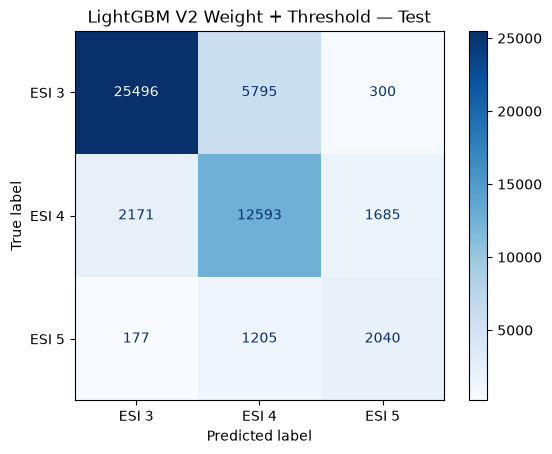

Saved test metrics: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/reports/lightgbm_v2_test_metrics.json
Saved validation summary: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/reports/lightgbm_v2_validation_summary.csv


In [14]:
lgb_v2_val_proba = best_lgb_v2_model.predict(
    X_lgb_val,
    num_iteration=best_lgb_v2_model.best_iteration,
)

lgb_v2_test_proba = best_lgb_v2_model.predict(
    X_lgb_test,
    num_iteration=best_lgb_v2_model.best_iteration,
)

lgb_v2_val_pred = predict_with_esi5_threshold(lgb_v2_val_proba, best_lgb_v2_threshold)
lgb_v2_test_pred = predict_with_esi5_threshold(lgb_v2_test_proba, best_lgb_v2_threshold)

lgb_v2_val_metrics = evaluate_predictions(
    y_val,
    lgb_v2_val_pred,
    f"{MODEL_DISPLAY_NAME} — Validation",
    show_report=False,
    show_cm=False,
)

lgb_v2_test_metrics = evaluate_predictions(
    y_test,
    lgb_v2_test_pred,
    f"{MODEL_DISPLAY_NAME} — Test",
)

metrics_test_path = REPORTS_DIR / "lightgbm_v2_test_metrics.json"
with open(metrics_test_path, "w") as f:
    json.dump(lgb_v2_test_metrics, f, indent=2)

validation_summary_path = REPORTS_DIR / "lightgbm_v2_validation_summary.csv"
lgb_v2_validation_summary.to_csv(validation_summary_path, index=False)

print("Saved test metrics:", metrics_test_path)
print("Saved validation summary:", validation_summary_path)

## Section 14 — Probability calibration

### What I did
I checked raw model probabilities using multiclass Brier score and log loss, then tested isotonic and Platt-style calibration.

### Why I did it
Healthcare users should not blindly trust uncalibrated confidence values.

### How to explain it
"Prediction class and confidence reliability are different. Calibration checks whether a 70% confidence score behaves like 70% in reality."

In [16]:
def normalize_rows(proba, eps=1e-12):
    proba = np.asarray(proba, dtype=float)
    proba = np.clip(proba, eps, 1.0)
    return proba / proba.sum(axis=1, keepdims=True)

def multiclass_brier_score(y_true, proba, n_classes=3):
    y_true = np.asarray(y_true).astype(int)
    proba = normalize_rows(proba)
    y_onehot = np.eye(n_classes)[y_true]
    return float(np.mean(np.sum((proba - y_onehot) ** 2, axis=1)))

def fit_isotonic_calibrators(y_cal, proba_cal, n_classes=3):
    calibrators = []
    y_cal = np.asarray(y_cal).astype(int)

    for k in range(n_classes):
        y_binary = (y_cal == k).astype(int)
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(proba_cal[:, k], y_binary)
        calibrators.append(iso)

    return calibrators

def apply_isotonic_calibration(proba, calibrators):
    calibrated = np.column_stack([
        calibrator.predict(proba[:, k])
        for k, calibrator in enumerate(calibrators)
    ])
    return normalize_rows(calibrated)

calibration_rows = []

calibration_rows.append({
    "method": "raw_lightgbm_probability",
    "test_brier": multiclass_brier_score(y_test, lgb_v2_test_proba),
    "test_log_loss": log_loss(y_test, normalize_rows(lgb_v2_test_proba), labels=[0, 1, 2]),
})

isotonic_calibrators = fit_isotonic_calibrators(y_val, lgb_v2_val_proba)
lgb_v2_test_proba_isotonic = apply_isotonic_calibration(lgb_v2_test_proba, isotonic_calibrators)

calibration_rows.append({
    "method": "isotonic_one_vs_rest_validation_calibrated",
    "test_brier": multiclass_brier_score(y_test, lgb_v2_test_proba_isotonic),
    "test_log_loss": log_loss(y_test, normalize_rows(lgb_v2_test_proba_isotonic), labels=[0, 1, 2]),
})

platt_calibrator = LogisticRegression(max_iter=1000, solver="lbfgs")
platt_calibrator.fit(lgb_v2_val_proba, y_val)
lgb_v2_test_proba_platt = platt_calibrator.predict_proba(lgb_v2_test_proba)

calibration_rows.append({
    "method": "platt_logistic_validation_calibrated",
    "test_brier": multiclass_brier_score(y_test, lgb_v2_test_proba_platt),
    "test_log_loss": log_loss(y_test, normalize_rows(lgb_v2_test_proba_platt), labels=[0, 1, 2]),
})

calibration_report = pd.DataFrame(calibration_rows).sort_values("test_brier")
display(calibration_report)

calibration_report_path = REPORTS_DIR / "probability_calibration_report.csv"
calibration_report.to_csv(calibration_report_path, index=False)

selected_calibration_method = "raw_lightgbm_probability"
selected_calibrator = None

if calibration_report.iloc[0]["method"] != "raw_lightgbm_probability":
    print("Calibration challenger improved probability score. Review decision metrics before production use.")
else:
    print("Raw LightGBM probabilities remain default.")

# ESI 5 reliability curve data
def reliability_curve_table(y_true, proba, class_index=2, n_bins=10):
    y_binary = (np.asarray(y_true) == class_index).astype(int)
    p = np.asarray(proba)[:, class_index]
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(p, bins) - 1

    rows = []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        rows.append({
            "bin": b,
            "mean_predicted_probability": float(p[mask].mean()),
            "observed_frequency": float(y_binary[mask].mean()),
            "count": int(mask.sum()),
        })

    return pd.DataFrame(rows)

esi5_reliability_df = reliability_curve_table(y_test, lgb_v2_test_proba, class_index=2)
esi5_reliability_df.to_csv(REPORTS_DIR / "esi5_reliability_curve_raw.csv", index=False)
display(esi5_reliability_df)

,method,test_brier,test_log_loss
2,platt_logistic_validation_calibrated,0.281193,0.480779
1,isotonic_one_vs_rest_validation_calibrated,0.282321,0.479481
0,raw_lightgbm_probability,0.311712,0.537497


Calibration challenger improved probability score. Review decision metrics before production use.


,bin,mean_predicted_probability,observed_frequency,count
0,0,0.027965,0.005821,32642
1,1,0.142184,0.042339,7440
2,2,0.245101,0.080381,3359
3,3,0.347034,0.110778,2004
4,4,0.447984,0.174006,1408
5,5,0.549220,0.259574,1175
6,6,0.649691,0.345946,925
7,7,0.745717,0.441913,878
8,8,0.855652,0.650847,885
9,9,0.928666,0.792225,746


## Section 15 — Fairness and subgroup evaluation

### What I did
I evaluated performance by age group, gender, arrival mode, complaint group, and missing-vital group.

### Why I did it
Bias can appear indirectly even after risky columns are removed.

### How to explain it
"I removed risky columns, but I still test subgroup performance because proxies can still create uneven outcomes."

In [17]:
def add_subgroup_columns(df_part):
    out = df_part.copy()

    if "age" in out.columns:
        out["age_group_eval"] = pd.cut(
            pd.to_numeric(out["age"], errors="coerce"),
            bins=[-np.inf, 17, 44, 64, np.inf],
            labels=["0-17", "18-44", "45-64", "65+"],
        ).astype(str)
    else:
        out["age_group_eval"] = "Unknown"

    if "gender" not in out.columns:
        out["gender"] = "Unknown"

    if "arrivalmode" not in out.columns:
        out["arrivalmode"] = "Unknown"

    out["missing_vital_group_eval"] = np.where(
        out.get("total_vitals_missing", pd.Series(0, index=out.index)).astype(float) >= 3,
        "3+ missing vitals",
        "0-2 missing vitals",
    )

    def primary_complaint_group(row):
        for col in complaint_group_cols:
            if int(row.get(col, 0) or 0) == 1:
                return col.replace("cc_group_", "")
        return "other_or_unknown"

    out["primary_complaint_group_eval"] = out.apply(primary_complaint_group, axis=1)
    return out

def subgroup_metrics_table(df_part, y_true, y_pred, group_col, min_n=100):
    df_eval = df_part.copy()
    df_eval["_y_true"] = np.asarray(y_true)
    df_eval["_y_pred"] = np.asarray(y_pred)

    rows = []
    for group_value, g in df_eval.groupby(group_col, dropna=False):
        if len(g) < min_n:
            continue

        metrics = evaluate_predictions(
            g["_y_true"].values,
            g["_y_pred"].values,
            f"{group_col}={group_value}",
            show_report=False,
            show_cm=False,
            verbose=False,
        )

        rows.append({
            "group_column": group_col,
            "group_value": str(group_value),
            "n": int(len(g)),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "esi5_f1": metrics["esi5_f1"],
            "esi3_to_esi5_rate": metrics["esi3_to_esi5_rate"],
        })

    return pd.DataFrame(rows).sort_values(["group_column", "macro_f1"], ascending=[True, True])

test_eval_df = add_subgroup_columns(test_df)

subgroup_tables = []
for group_col in [
    "age_group_eval",
    "gender",
    "arrivalmode",
    "primary_complaint_group_eval",
    "missing_vital_group_eval",
]:
    subgroup_tables.append(subgroup_metrics_table(test_eval_df, y_test, lgb_v2_test_pred, group_col))

fairness_report = pd.concat(subgroup_tables, ignore_index=True)
display(fairness_report)

fairness_report_path = REPORTS_DIR / "fairness_subgroup_evaluation.csv"
fairness_report.to_csv(fairness_report_path, index=False)

print("Saved fairness report:", fairness_report_path)

,group_column,group_value,n,accuracy,macro_f1,weighted_f1,esi5_f1,esi3_to_esi5_rate
0,age_group_eval,65+,11129,0.827298,0.674830,0.829375,0.575524,0.004462
1,age_group_eval,45-64,16685,0.771771,0.697725,0.779551,0.552318,0.009239
2,age_group_eval,18-44,23648,0.763067,0.700575,0.768716,0.539118,0.013208
3,gender,Male,20485,0.767000,0.690444,0.773447,0.519029,0.010195
4,gender,Female,30977,0.788230,0.708298,0.794976,0.567856,0.009076
5,arrivalmode,Missing,2343,0.634230,0.396725,0.572577,0.750000,0.645570
6,arrivalmode,Wheelchair,106,0.839623,0.497083,0.842909,0.000000,0.000000
7,arrivalmode,ambulance,12133,0.852963,0.521382,0.853382,0.102190,0.000783
8,arrivalmode,Other,391,0.721228,0.557300,0.729107,0.321429,0.032491
9,arrivalmode,Car,23921,0.767317,0.650303,0.771470,0.395731,0.006553


Saved fairness report: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/reports/fairness_subgroup_evaluation.csv


## Section 16 — SHAP explanations

### What I did
I added optional SHAP explainability for LightGBM.

### Why I did it
The app should show simple top factors influencing the decision-support result.

### How to explain it
"I use explanation wording carefully. I say top factors influenced the decision-support result, not that the model diagnosed the patient."

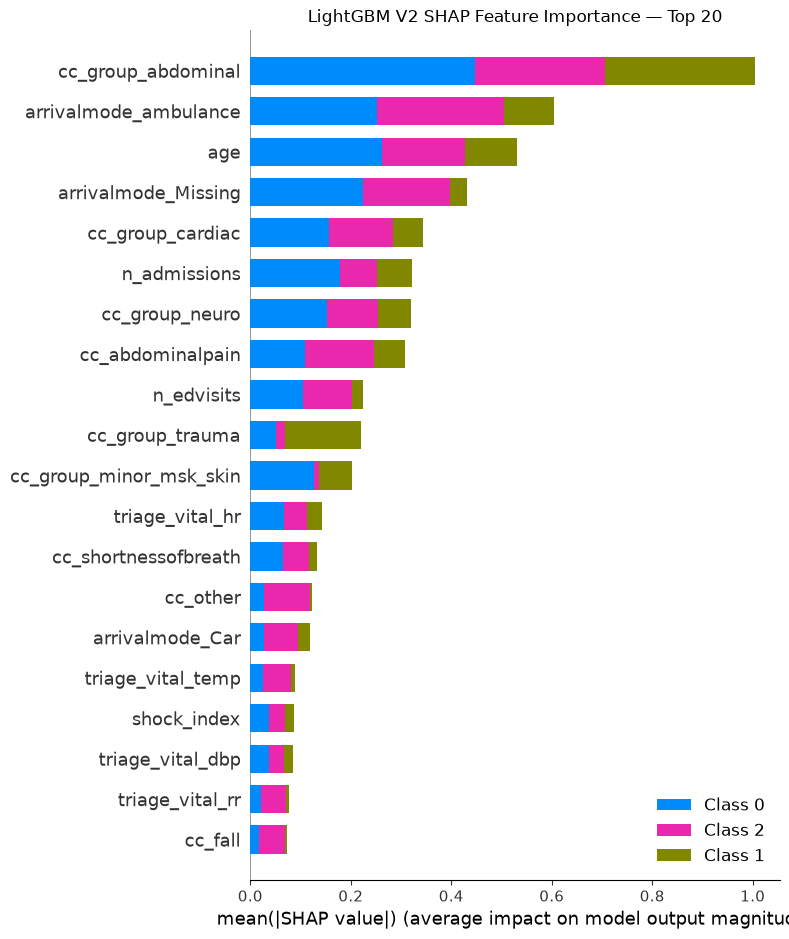

,feature,mean_abs_shap
29,cc_group_abdominal,0.334696
44,arrivalmode_ambulance,0.201320
0,age,0.177240
38,arrivalmode_Missing,0.143993
27,cc_group_cardiac,0.114355
2,n_admissions,0.107148
31,cc_group_neuro,0.106762
75,cc_abdominalpain,0.102815
1,n_edvisits,0.074495
30,cc_group_trauma,0.073553


In [19]:
RUN_SHAP = True

if RUN_SHAP:
    import shap

    shap_sample_size = min(3000, X_lgb_test.shape[0])
    X_shap = X_lgb_test[:shap_sample_size]

    explainer = shap.TreeExplainer(best_lgb_v2_model)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values,
        X_shap,
        feature_names=feature_columns_lgb,
        max_display=20,
        show=False,
        plot_type="bar",
    )
    plt.title("LightGBM V2 SHAP Feature Importance — Top 20")
    plt.tight_layout()
    plt.show()

    if isinstance(shap_values, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        arr = np.asarray(shap_values)
        if arr.ndim == 3:
            mean_abs = np.abs(arr).mean(axis=(0, 2))
        else:
            mean_abs = np.abs(arr).mean(axis=0)

    shap_importance = pd.DataFrame({
        "feature": feature_columns_lgb,
        "mean_abs_shap": mean_abs,
    }).sort_values("mean_abs_shap", ascending=False)

    shap_importance_path = REPORTS_DIR / "shap_global_feature_importance.csv"
    shap_importance.to_csv(shap_importance_path, index=False)
    display(shap_importance.head(25))
else:
    print("SHAP skipped. Set RUN_SHAP = True to generate explanation reports.")

## Section 17 — App-style prediction function

### What I did
I created a deployable one-patient prediction function.

### Why I did it
The app needs safety gate → preprocessing → model prediction → threshold decision → confidence output.

### How to explain it
"The deployed path is not just a model file. It is a full prediction workflow with safety, preprocessing, thresholding, and audit-ready output."

In [20]:
def transform_for_lgb(raw_df, artifacts):
    df_in = raw_df.copy()

    for col in artifacts["selected_feature_cols"]:
        if col not in df_in.columns:
            if col in artifacts["numeric_cols"] or col in artifacts["categorical_cols"]:
                df_in[col] = np.nan
            else:
                df_in[col] = 0

    cc_columns = artifacts["cc_cols"]
    df_in, _, _, _ = create_row_level_features(df_in, cc_columns)
    df_in, _ = apply_clinical_ranges(df_in)

    for col in artifacts["numeric_cols_extended"]:
        if col not in df_in.columns:
            df_in[col] = np.nan
        df_in[col] = pd.to_numeric(df_in[col], errors="coerce")
        df_in[col] = df_in[col].fillna(artifacts["numeric_medians"].get(col, 0.0))

    X_num = df_in[artifacts["existing_numeric_cols"]].astype("float32").values

    for col in artifacts["categorical_cols"]:
        if col not in df_in.columns:
            df_in[col] = "Missing"
        df_in[col] = df_in[col].fillna("Missing").astype(str)

    if artifacts["categorical_cols"]:
        X_cat = artifacts["onehot_encoder"].transform(df_in[artifacts["categorical_cols"]])
    else:
        X_cat = np.empty((len(df_in), 0))

    for col in cc_columns:
        if col not in df_in.columns:
            df_in[col] = 0
        df_in[col] = df_in[col].fillna(0).astype("int8")

    X_cc = df_in[cc_columns].astype("float32").values if cc_columns else np.empty((len(df_in), 0))
    X = np.hstack([X_num, X_cat.astype("float32"), X_cc])

    expected_n = len(artifacts["feature_columns_lgb"])
    if X.shape[1] != expected_n:
        raise ValueError(f"Feature mismatch. Got {X.shape[1]}, expected {expected_n}.")

    return X, df_in

def make_decision_output(proba, esi5_threshold, model_name=MODEL_DISPLAY_NAME):
    proba = np.asarray(proba).reshape(1, -1)
    pred_label = int(predict_with_esi5_threshold(proba.copy(), esi5_threshold)[0])
    confidence = float(proba[0, pred_label])

    return {
        "model_version": MODEL_VERSION,
        "model_name": model_name,
        "predicted_label": pred_label,
        "predicted_esi": int(reverse_label_map[pred_label]),
        "class_name": class_names[pred_label],
        "confidence": confidence,
        "prob_esi3": float(proba[0, 0]),
        "prob_esi4": float(proba[0, 1]),
        "prob_esi5": float(proba[0, 2]),
        "low_confidence_review": confidence < CONFIDENCE_THRESHOLD,
        "esi5_threshold": float(esi5_threshold),
        "decision_support_note": (
            "Clinical decision-support result for ESI 3/4/5 only. "
            "Not a diagnosis and not a replacement for clinician judgment."
        ),
    }

def predict_single_patient(patient_dict, model, artifacts):
    raw = pd.DataFrame([patient_dict])

    gate_df, _, _, _ = create_row_level_features(raw, artifacts["cc_cols"])
    gate_result = apply_esi12_safety_gate(gate_df.iloc[0])

    if gate_result["safety_gate_triggered"]:
        return {
            "model_version": MODEL_VERSION,
            "safety_gate_triggered": True,
            "red_flags": gate_result["red_flags"],
            "recommended_route": gate_result["recommended_route"],
            "prediction_skipped_reason": "ESI 1/2 red-flag safety gate triggered before ESI 3/4/5 model.",
            "decision_support_note": gate_result["safety_gate_note"],
        }

    X, transformed_df = transform_for_lgb(raw, artifacts)
    proba = model.predict(X, num_iteration=model.best_iteration)

    output = make_decision_output(
        proba[0],
        esi5_threshold=artifacts["best_lgb_v2_threshold"],
        model_name=MODEL_DISPLAY_NAME,
    )
    output["safety_gate_triggered"] = False
    output["red_flags"] = []
    output["recommended_route"] = "esi_3_4_5_decision_support"
    return output

in_memory_artifacts = {
    "selected_feature_cols": selected_feature_cols,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "cc_cols": cc_cols,
    "numeric_cols_extended": numeric_cols_extended,
    "existing_numeric_cols": existing_numeric_cols,
    "numeric_medians": numeric_medians,
    "onehot_encoder": onehot_encoder,
    "feature_columns_lgb": feature_columns_lgb,
    "best_lgb_v2_threshold": best_lgb_v2_threshold,
}

sample_patient = test_df.iloc[0][selected_feature_cols].to_dict()
sample_prediction = predict_single_patient(sample_patient, best_lgb_v2_model, in_memory_artifacts)
sample_prediction

{'model_version': 'lightgbm_v2_weight_threshold_esi345',
 'model_name': 'LightGBM V2 Weight + Threshold',
 'predicted_label': 1,
 'predicted_esi': 4,
 'class_name': 'ESI 4',
 'confidence': 0.4998892818293546,
 'prob_esi3': 0.4231167948313043,
 'prob_esi4': 0.4998892818293546,
 'prob_esi5': 0.07699392333934105,
 'low_confidence_review': True,
 'esi5_threshold': 0.55,
 'decision_support_note': 'Clinical decision-support result for ESI 3/4/5 only. Not a diagnosis and not a replacement for clinician judgment.',
 'safety_gate_triggered': False,
 'red_flags': [],
 'recommended_route': 'esi_3_4_5_decision_support'}

## Section 18 — Monitoring and audit trail

### What I did
I created a JSONL audit logging template.

### Why I did it
Healthcare decision-support systems need traceability: model version, confidence, final acuity, rule escalation, clinician accept/override, and timestamp.

### How to explain it
"Every prediction should be auditable. Clinician overrides become important future feedback signals."

In [21]:
def log_prediction_event(
    prediction_id,
    prediction_output,
    patient_reference=None,
    clinician_action=None,
    clinician_final_esi=None,
    clinician_note=None,
    audit_log_path=AUDIT_LOG_PATH,
):
    record = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "prediction_id": prediction_id,
        "patient_reference": patient_reference,
        "model_version": prediction_output.get("model_version"),
        "model_name": prediction_output.get("model_name"),
        "safety_gate_triggered": prediction_output.get("safety_gate_triggered"),
        "red_flags": prediction_output.get("red_flags", []),
        "recommended_route": prediction_output.get("recommended_route"),
        "predicted_esi": prediction_output.get("predicted_esi"),
        "confidence": prediction_output.get("confidence"),
        "prob_esi3": prediction_output.get("prob_esi3"),
        "prob_esi4": prediction_output.get("prob_esi4"),
        "prob_esi5": prediction_output.get("prob_esi5"),
        "low_confidence_review": prediction_output.get("low_confidence_review"),
        "clinician_action": clinician_action,
        "clinician_final_esi": clinician_final_esi,
        "clinician_note": clinician_note,
    }

    audit_log_path = Path(audit_log_path)
    audit_log_path.parent.mkdir(parents=True, exist_ok=True)

    with open(audit_log_path, "a") as f:
        f.write(json.dumps(record) + "\n")

    return record

sample_audit = log_prediction_event(
    prediction_id="sample-001",
    prediction_output=sample_prediction,
    patient_reference="demo_patient",
    clinician_action="pending",
)

sample_audit

{'timestamp_utc': '2026-07-06T23:06:51.165593+00:00',
 'prediction_id': 'sample-001',
 'patient_reference': 'demo_patient',
 'model_version': 'lightgbm_v2_weight_threshold_esi345',
 'model_name': 'LightGBM V2 Weight + Threshold',
 'safety_gate_triggered': False,
 'red_flags': [],
 'recommended_route': 'esi_3_4_5_decision_support',
 'predicted_esi': 4,
 'confidence': 0.4998892818293546,
 'prob_esi3': 0.4231167948313043,
 'prob_esi4': 0.4998892818293546,
 'prob_esi5': 0.07699392333934105,
 'low_confidence_review': True,
 'clinician_action': 'pending',
 'clinician_final_esi': None,
 'clinician_note': None}

## Section 19 — Save final deployment artifacts

### What I did
I save all production-critical artifacts into one deployment folder.

### Why I did it
Saving only the model is not enough. The app also needs exact feature order, medians, encoder, threshold, and label mapping.

### How to explain it
"The deployment folder contains everything required to reproduce the same prediction pipeline in the app."

In [22]:
model_path = OUTPUT_DIR / "esi_345_lightgbm_v2_model.txt"
best_lgb_v2_model.save_model(str(model_path))

optional_experiment_artifacts = {
    "scaler_dense": None,
    "scaler_struct": None,
    "tokenizer": None,
    "note": (
        "Scaler/tokenizer are not required for the final LightGBM V2 deployment model. "
        "They are only needed if neural/RNN/GRU experiments are deployed later."
    ),
}

preprocessing_artifacts = {
    "model_version": MODEL_VERSION,
    "model_display_name": MODEL_DISPLAY_NAME,
    "feature_policy": {
        "blocked_risky_cols": blocked_risky_cols,
        "use_previousdispo": USE_PREVIOUS_DISPO,
        "selected_feature_cols": selected_feature_cols,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "numeric_cols_extended": numeric_cols_extended,
        "clinical_feature_cols": clinical_feature_cols,
        "complaint_group_cols": complaint_group_cols,
        "complaint_group_specs": complaint_group_specs,
        "cc_cols": cc_cols,
    },
    "selected_feature_cols": selected_feature_cols,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "cc_cols": cc_cols,
    "numeric_cols_extended": numeric_cols_extended,
    "existing_numeric_cols": existing_numeric_cols,
    "numeric_medians": numeric_medians,
    "onehot_encoder": onehot_encoder,
    "feature_columns_lgb": feature_columns_lgb,
    "raw_feature_columns_lgb": raw_feature_columns_lgb,
    "label_map": label_map,
    "reverse_label_map": reverse_label_map,
    "class_names": class_names,
    "class_weights_base": class_weights,
    "class_weights_final_v2": best_lgb_v2_class_weights,
    "best_lgb_v2_multiplier": best_lgb_v2_multiplier,
    "best_lgb_v2_threshold": best_lgb_v2_threshold,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "clinical_ranges": clinical_ranges,
    "safety_gate_config": SAFETY_GATE_CONFIG,
    "calibration": {
        "selected_calibration_method": selected_calibration_method,
        "isotonic_calibrators": isotonic_calibrators,
        "platt_calibrator": platt_calibrator,
        "calibration_report_path": str(calibration_report_path),
        "note": (
            "Raw LightGBM probabilities remain default unless a calibration challenger "
            "improves probability quality without harming decision metrics."
        ),
    },
    "optional_experiment_artifacts": optional_experiment_artifacts,
}

artifacts_path = OUTPUT_DIR / "esi_345_lightgbm_v2_preprocessing_artifacts.joblib"
joblib.dump(preprocessing_artifacts, artifacts_path)

feature_list_path = OUTPUT_DIR / "esi_345_lightgbm_v2_feature_list.json"
with open(feature_list_path, "w") as f:
    json.dump(feature_columns_lgb, f, indent=2)

threshold_config_path = OUTPUT_DIR / "esi_345_lightgbm_v2_threshold_config.json"
with open(threshold_config_path, "w") as f:
    json.dump({
        "model_version": MODEL_VERSION,
        "best_lgb_v2_threshold": best_lgb_v2_threshold,
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "selection_rule": (
            "Selected on validation using ESI 5 F1, Macro F1, and unsafe ESI 3-to-ESI 5 "
            f"rate <= {V2_MAX_ESI3_TO_ESI5_RATE:.3f}."
        ),
    }, f, indent=2)

label_mapping_path = OUTPUT_DIR / "esi_345_label_mapping.json"
with open(label_mapping_path, "w") as f:
    json.dump({
        "label_map": {str(k): int(v) for k, v in label_map.items()},
        "reverse_label_map": {str(k): int(v) for k, v in reverse_label_map.items()},
        "class_names": class_names,
    }, f, indent=2)

deployment_config_path = OUTPUT_DIR / "esi_345_deployment_config.json"
with open(deployment_config_path, "w") as f:
    json.dump({
        "project": "TriageAI / SympDirect",
        "task": "client_focused_esi_3_4_5",
        "model_version": MODEL_VERSION,
        "model_display_name": MODEL_DISPLAY_NAME,
        "model_file": model_path.name,
        "preprocessing_artifacts_file": artifacts_path.name,
        "feature_list_file": feature_list_path.name,
        "threshold_config_file": threshold_config_path.name,
        "label_mapping_file": label_mapping_path.name,
        "target_source_column": "esi",
        "derived_label_column": "esi_label",
        "important_warning": "This model excludes ESI 1 and ESI 2. Use the safety gate before this model.",
        "clinical_safety_wording": "Decision support only. Not a diagnostic tool. Does not replace clinicians.",
    }, f, indent=2)

artifact_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "model_version": MODEL_VERSION,
    "required_deployment_artifacts": {
        "model_file": str(model_path),
        "feature_list": str(feature_list_path),
        "onehot_encoder_and_medians": str(artifacts_path),
        "threshold_config": str(threshold_config_path),
        "label_mapping": str(label_mapping_path),
        "deployment_config": str(deployment_config_path),
    },
    "reports": {
        "test_metrics": str(metrics_test_path),
        "validation_summary": str(validation_summary_path),
        "calibration_report": str(calibration_report_path),
        "fairness_subgroup_report": str(fairness_report_path),
    },
    "optional_not_deployed": {
        "scaler": "not required for LightGBM V2 deployment",
        "tokenizer": "not required for LightGBM V2 deployment",
    },
}

manifest_path = OUTPUT_DIR / "artifact_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(artifact_manifest, f, indent=2)

print("Saved final deployment artifacts:")
for k, v in artifact_manifest["required_deployment_artifacts"].items():
    print(f"  {k}: {v}")

Saved final deployment artifacts:
  model_file: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_lightgbm_v2_model.txt
  feature_list: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_lightgbm_v2_feature_list.json
  onehot_encoder_and_medians: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_lightgbm_v2_preprocessing_artifacts.joblib
  threshold_config: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_lightgbm_v2_threshold_config.json
  label_mapping: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_label_mapping.json
  deployment_config: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_deployment_config.json


## Section 20 — Confirm deployed artifacts

### What I did
I verify that all required deployment files exist and can be loaded.

### Why I did it
Deployment breaks if the app is missing the model, encoder, medians, threshold, feature order, or label mapping.

### How to explain it
"I added a final deployment readiness check before using the artifacts in the app."

In [23]:
required_paths = [
    model_path,
    artifacts_path,
    feature_list_path,
    threshold_config_path,
    label_mapping_path,
    deployment_config_path,
    manifest_path,
    metrics_test_path,
    validation_summary_path,
    calibration_report_path,
    fairness_report_path,
]

missing = [str(p) for p in required_paths if not Path(p).exists()]

if missing:
    raise FileNotFoundError(f"Missing deployment artifacts: {missing}")

loaded_artifacts = joblib.load(artifacts_path)

assert loaded_artifacts["feature_columns_lgb"] == feature_columns_lgb
assert loaded_artifacts["label_map"] == label_map
assert loaded_artifacts["reverse_label_map"] == reverse_label_map
assert "onehot_encoder" in loaded_artifacts
assert "numeric_medians" in loaded_artifacts
assert "best_lgb_v2_threshold" in loaded_artifacts

print("Deployment artifact check PASSED.")
print("Final model file:", model_path)
print("Final preprocessing artifacts:", artifacts_path)
print("Final threshold:", loaded_artifacts["best_lgb_v2_threshold"])
print("Feature count:", len(loaded_artifacts["feature_columns_lgb"]))

Deployment artifact check PASSED.
Final model file: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_lightgbm_v2_model.txt
Final preprocessing artifacts: /Users/chintanpatel/Desktop/My/triageai-esi-care-routing/model_registry/esi_345_lightgbm_v2/esi_345_lightgbm_v2_preprocessing_artifacts.joblib
Final threshold: 0.55
Feature count: 273


## Section 21 — Final explanation to remember

### What I did
I created one final deployment source-of-truth notebook for the ESI 3/4/5 model. It uses the clean final pipeline structure and the stronger V2 LightGBM class-weight + threshold search.

### Why I did it
The Final Clean notebook had the best clean structure, but V2 had the better deployment candidate metrics. This notebook combines both.

### How to explain it

> I built one final deployment notebook for the TriageAI/SympDirect ESI 3/4/5 model. The final champion is LightGBM V2 with class weighting and ESI 5 threshold tuning. I selected it because it gave the best clinical-safe balance across Macro F1, ESI 5 F1, and low unsafe ESI 3-to-ESI 5 downgrade rate.
>
> The workflow is leakage-safe because the data is split before fitting preprocessing. Numeric medians, one-hot encoding, class weights, threshold selection, calibration checks, fairness evaluation, and deployment artifact saving are all handled in one place.
>
> Since this model only predicts ESI 3/4/5, I added an ESI 1/2 safety gate before model prediction. If red flags are present, the model is skipped and the case is routed to urgent clinician review or an ESI 1/2 escalation pathway.
>
> The saved deployment folder includes the LightGBM model, feature list, one-hot encoder, numeric medians, threshold config, label mapping, calibration report, fairness report, and artifact manifest. The model is clinical decision support only and does not replace clinicians.

## Section 22 — Future work after deployment

### 1. Connect artifacts to the app/backend
Use:
- `esi_345_lightgbm_v2_model.txt`
- `esi_345_lightgbm_v2_preprocessing_artifacts.joblib`
- `esi_345_lightgbm_v2_threshold_config.json`
- `esi_345_label_mapping.json`

### 2. Run the safety gate before prediction
If red flags are present, skip the ESI 3/4/5 model and route to urgent clinician review or ESI 1/2 escalation.

### 3. Show SHAP explanations carefully
Use wording:

> Top factors influencing the decision-support result.

Avoid wording:

> The model diagnosed the patient.

### 4. Log monitoring and audit fields
Track:
- prediction ID
- model version
- confidence
- probabilities
- safety gate result
- final acuity
- clinician accept/override
- timestamp
- low-confidence review flag

### 5. Monitor over time
Track:
- data drift
- confidence drift
- subgroup performance
- unsafe downgrade rate
- clinician override patterns

### 6. Later text representation challenger strategy
Keep LightGBM V2 as the stable production baseline.

Future challenger experiments should be tested in this order:

1. TF-IDF complaint text + LightGBM
2. Sentence-transformer embeddings + LightGBM
3. ClinicalBERT/BioClinicalBERT embeddings only if complaint text is rich enough

Do **not** replace LightGBM unless the challenger clearly improves:
- Macro F1
- ESI 5 F1
- calibration
- unsafe ESI 3 → ESI 5 downgrade rate
- latency/cost/deployment practicality